# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp. 

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
Het verwarmingselement geeft 10 W, dus 10 J/s, dus elke seconde worden er 10 joules aan energie overgedragen. Als de tijd waarbij de spanningsbron aanstaat gemeten word en de warmte op een bepaalde tijd, is daarbij te bepalen hoeveel joules er nodig zijn om water op te warmen tot een bepaalde temperatuur.
1. doe 500 ml water in de beker
2. doe de temperatuurmeter erin
3. sluit het verwarmingselement aan en doe het ook in het water (zorg dat het volledig onder water is)
4. noteer de beginwarmte
5. zet de spanningsbron aan en start de stopwatch tegelijkertijd
6. doe een aantal metingen en noteer de tijden

```


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

# Resultaten


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

P=40 #watt
V= 0.6/1000 #m^3
P_water = 0.997*1000 #kg/m^3
c_w_echt = 4186 #J/kgK

T=np.array([18.5, 18.8,19.3,19.4,19.5,19.7])+273.15 #K
t=np.array([0, 30.6,40.3,41.5,44.3,52.9]) #s

E = P*t #J
m_water = P_water*V #kg
c_w = E[1:]/(m_water*(T[1:]-T[0]))
print(f"de berekende soortelijke warmte van water:{np.mean(c_w):.2f} J/kgK")

de berekende soortelijke warmte van water:3836.44 J/kgK


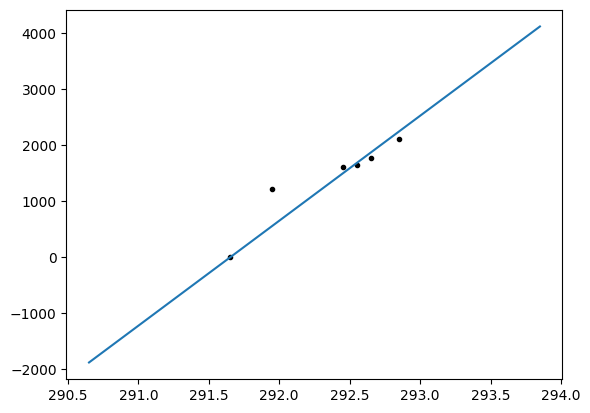

de gevonden soortelijke warmte is:3134.19 J/kgK
percentage verschil eerste c en echte c: 8.35 %
percentage verschil tweede c en echte c: 25.13 %


In [70]:
def func(x,c):
    return c*m_water*(x-T[0])

popt,pcov=curve_fit(func,T,E)
xtest=np.linspace(np.min(T)-1,np.max(T)+1,1000)
ytest=func(xtest,*popt)
plt.figure()
plt.plot(T,E,'k.')
plt.plot(xtest,ytest)
plt.savefig("Figuren/cwater.png", dpi=450)
plt.show()
print(f"de gevonden soortelijke warmte is:{popt[0]:.2f} J/kgK")
verschil_c1 = c_w_echt-np.mean(c_w)
verschil_c2 = c_w_echt-popt[0]
percentage_verschil_c1 = verschil_c1/c_w_echt*100
percentage_verschil_c2 = verschil_c2/c_w_echt*100
print(f"percentage verschil eerste c en echte c: {percentage_verschil_c1:.2f} %")
print(f"percentage verschil tweede c en echte c: {percentage_verschil_c2:.2f} %")

# Discussie en conclusie

We hebben hier twee manieren gebruikt om c te vinden.
Eerst hebben we de gemiddelde soortelijke warmte van elk punt genomen. Daar kwamen we uit op 3836 J/kgK. Dit is best wat lager dan de verwachtte waarde van 4186 J/kgK (8% lager). We hebben daarna ook met een fit geprobeerd c te vinden, maar dit is nog veel lager. We hebben veel te weinig punten gemeten omdat we vroeg moesten stoppen, dus de waarden die we hier hebben gevonden zijn ook niet erg betrouwbaar. Wel was de cw waarschijnlijk nog steeds te laag zelfs al hadden we meer punten, want er is warmte verloren aan de omgeving. Verder was het ook beter geweest om meer tijd te nemen, zodat het water meer gelijkmatig verwarmt, en zodat het verwarmingselement tijd heeft om de warmte over te dragen (dan kan er ook een lager vermogen gebruikt worden).